## **Imports**

In [1]:
import os
import sys
from pathlib import Path
from IPython.display import display

PROJECT_FOLDER_NAME = "nature_inspired_optimization_algorithms_comperative"
current_dir = Path(os.getcwd())

if PROJECT_FOLDER_NAME in current_dir.parts:
    target_idx = current_dir.parts.index(PROJECT_FOLDER_NAME) + 1
    project_root = Path(*current_dir.parts[:target_idx])
else:
    project_root = current_dir / PROJECT_FOLDER_NAME

raw_path = project_root / "data" / "raw"
if not raw_path.exists():
    raise FileNotFoundError(f"Critical Error: Absolute path resolution failed -> {raw_path.resolve()}")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils.statistics_engine import StatisticsEngine

# Initialize the engine
engine = StatisticsEngine(
    raw_data_dir=str(raw_path), 
    processed_dir=str(project_root / "data" / "processed"), 
    figures_dir=str(project_root / "outputs" / "statistics")
)

[INFO] Successfully loaded 1350 records into the analytical matrix.


## **Central Tendency and Distribution**

In [ ]:
%pip install nest_asyncio

In [ ]:
%pip install Jinja2

In [2]:
import dataframe_image as dfi
import nest_asyncio
import numpy as np

nest_asyncio.apply()

def sci_notation(val):
    if isinstance(val, (int, float)):
        if val == 0: return "0.00"
        # Small p-values or fitness values
        exponent = int(np.floor(np.log10(abs(val))))
        coeff = val / pow(10, exponent)
        return f"{coeff:.2f} &times; 10<sup>{exponent}</sup>"
    return val

dispersion_df = engine.get_dispersion_tables()
fitness_cols = ['Best', 'Worst', 'Mean', 'Std']

# Significance Styling: Green for proven success (low p-value)
def color_significance(val):
    if isinstance(val, float) and val < 0.05:
        return 'background-color: #d1e7dd; color: #0f5132; font-weight: bold' # Successful significance
    return ''

css_styles = [
    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('margin-bottom', '12px')]},
    {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('padding', '10px'), ('border', '1px solid #ccc')]},
    {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'sup', 'props': [('vertical-align', 'baseline'), ('position', 'relative'), ('top', '-0.4em'), ('font-size', '0.75em')]}
]

for dim in sorted(dispersion_df['Dimension'].unique()):
    dim_data = dispersion_df[dispersion_df['Dimension'] == dim].drop(columns=['Dimension'])
    
    dim_data = dim_data[['Algorithm', 'Function', 'SR', 'p-value (SR)', 'Best', 'Worst', 'Mean', 'Std']]
    dim_data = dim_data.sort_values(by=['Algorithm', 'Function']).reset_index(drop=True)
    
    styled_table = (dim_data.style
        .hide(axis="index")
        .set_caption(f"Reliability & Performance Analysis - D:{dim}")
        .applymap(color_significance, subset=['p-value (SR)'])
        .background_gradient(subset=fitness_cols, cmap='Blues', vmin=1e-8, vmax=1e-2)
        .background_gradient(subset=['SR'], cmap='YlGn', vmin=0, vmax=100)
        .format(sci_notation, subset=fitness_cols + ['p-value (SR)'])
        .format("{:.1f}%", subset=['SR'])
        .set_table_styles(css_styles)
    )
    
    display(styled_table)
    
    output_path = engine.figures_dir / f"reliability_table_D{dim}.png"
    try:
        dfi.export(styled_table, str(output_path), dpi=300, table_conversion="chrome")
    except: pass

Algorithm,Function,SR,p-value (SR),Best,Worst,Mean,Std
ABC,ackley,100.0%,1.86 × 10-9,5.98 × 10-9,9.86 × 10-9,8.62 × 10-9,1.11 × 10-9
ABC,sphere,100.0%,1.86 × 10-9,1.50 × 10-9,9.98 × 10-9,7.06 × 10-9,2.25 × 10-9
ABC,zakharov,0.0%,1.86 × 10-9,1.02 × 10-2,7.50 × 10-1,1.37 × 10-1,1.54 × 10-1
DE,ackley,100.0%,1.86 × 10-9,7.78 × 10-9,9.96 × 10-9,9.10 × 10-9,6.77 × 10-10
DE,sphere,100.0%,1.86 × 10-9,4.47 × 10-9,9.99 × 10-9,7.77 × 10-9,1.64 × 10-9
DE,zakharov,100.0%,1.86 × 10-9,5.26 × 10-9,9.94 × 10-9,7.94 × 10-9,1.35 × 10-9
ES,ackley,100.0%,1.86 × 10-9,6.53 × 10-9,9.97 × 10-9,9.06 × 10-9,8.85 × 10-10
ES,sphere,100.0%,1.86 × 10-9,4.88 × 10-9,9.96 × 10-9,8.79 × 10-9,1.27 × 10-9
ES,zakharov,100.0%,1.86 × 10-9,3.60 × 10-9,9.87 × 10-9,7.90 × 10-9,1.79 × 10-9
GWO,ackley,0.0%,1.86 × 10-9,4.41 × 10-3,2.46 × 100,8.28 × 10-1,7.50 × 10-1


Algorithm,Function,SR,p-value (SR),Best,Worst,Mean,Std
ABC,ackley,100.0%,1.86 × 10-9,5.91 × 10-9,9.97 × 10-9,8.70 × 10-9,1.19 × 10-9
ABC,sphere,100.0%,1.86 × 10-9,3.08 × 10-9,9.99 × 10-9,8.18 × 10-9,1.91 × 10-9
ABC,zakharov,0.0%,1.86 × 10-9,8.79 × 100,3.96 × 101,2.31 × 101,9.42 × 100
DE,ackley,100.0%,1.86 × 10-9,7.78 × 10-9,9.89 × 10-9,9.11 × 10-9,5.69 × 10-10
DE,sphere,100.0%,1.86 × 10-9,4.93 × 10-9,9.99 × 10-9,8.72 × 10-9,1.16 × 10-9
DE,zakharov,100.0%,1.86 × 10-9,6.42 × 10-9,9.79 × 10-9,8.59 × 10-9,8.98 × 10-10
ES,ackley,100.0%,1.86 × 10-9,7.88 × 10-9,9.96 × 10-9,9.65 × 10-9,4.05 × 10-10
ES,sphere,100.0%,1.86 × 10-9,5.95 × 10-9,9.98 × 10-9,8.72 × 10-9,1.03 × 10-9
ES,zakharov,100.0%,1.86 × 10-9,5.35 × 10-9,10.00 × 10-9,8.78 × 10-9,1.19 × 10-9
GWO,ackley,0.0%,1.86 × 10-9,5.91 × 10-1,5.75 × 100,3.24 × 100,1.39 × 100


Algorithm,Function,SR,p-value (SR),Best,Worst,Mean,Std
ABC,ackley,100.0%,1.86 × 10-9,5.71 × 10-9,9.98 × 10-9,8.71 × 10-9,1.25 × 10-9
ABC,sphere,100.0%,1.86 × 10-9,5.11 × 10-9,9.99 × 10-9,8.06 × 10-9,1.55 × 10-9
ABC,zakharov,0.0%,1.86 × 10-9,2.67 × 101,1.17 × 102,6.46 × 101,2.66 × 101
DE,ackley,93.3%,8.68 × 10-7,6.69 × 10-9,1.23 × 10-8,9.47 × 10-9,8.72 × 10-10
DE,sphere,100.0%,1.86 × 10-9,6.95 × 10-9,9.96 × 10-9,8.97 × 10-9,8.29 × 10-10
DE,zakharov,0.0%,1.86 × 10-9,2.74 × 10-2,3.04 × 10-1,1.11 × 10-1,6.57 × 10-2
ES,ackley,100.0%,1.86 × 10-9,8.75 × 10-9,9.92 × 10-9,9.54 × 10-9,3.23 × 10-10
ES,sphere,100.0%,1.86 × 10-9,7.36 × 10-9,10.00 × 10-9,9.14 × 10-9,6.58 × 10-10
ES,zakharov,100.0%,1.86 × 10-9,7.24 × 10-9,9.96 × 10-9,9.25 × 10-9,5.66 × 10-10
GWO,ackley,0.0%,1.86 × 10-9,1.56 × 100,7.99 × 100,4.46 × 100,1.54 × 100


## **Wilcoxon Rank-Sum Test**

In [ ]:
wilcoxon_df = engine.get_wilcoxon_matrix()

display(wilcoxon_df[wilcoxon_df['Dimension'] == 30])

,Dimension,Function,Control_Algo,Tested_Algo,p-value,Significance
30,30,ackley,ABC,ABC,NaN,CTRL
31,30,ackley,ABC,DE,5.843685e-02,=
32,30,ackley,ABC,ES,8.634645e-02,=
33,30,ackley,ABC,GWO,2.871949e-11,+
34,30,ackley,ABC,PSO,1.204598e-03,+
35,30,sphere,ABC,ABC,NaN,CTRL
36,30,sphere,ABC,DE,3.710526e-02,+
37,30,sphere,ABC,ES,1.354916e-02,+
38,30,sphere,ABC,GWO,2.871949e-11,+
39,30,sphere,ABC,PSO,8.401202e-05,+


## **Scalability Analysis**

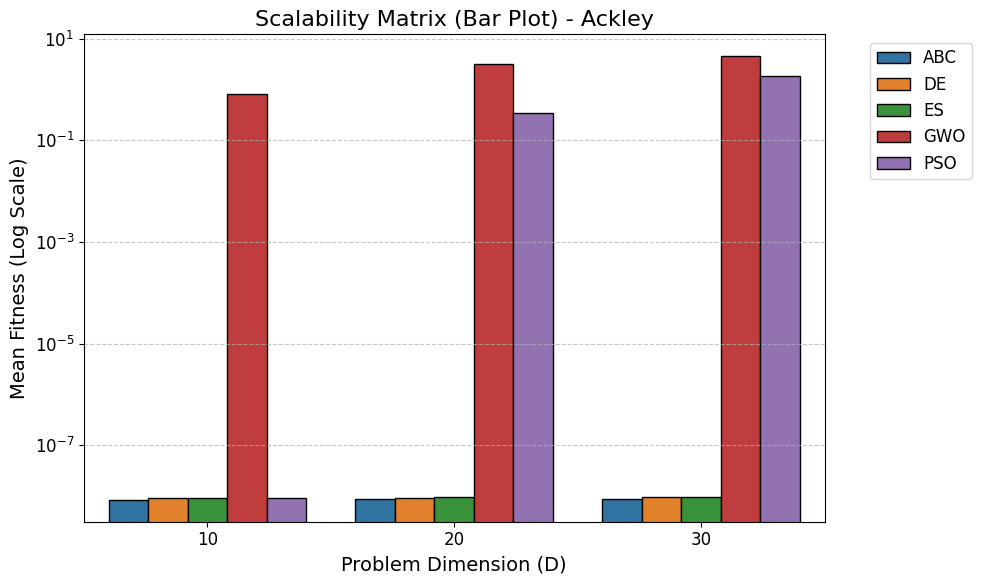

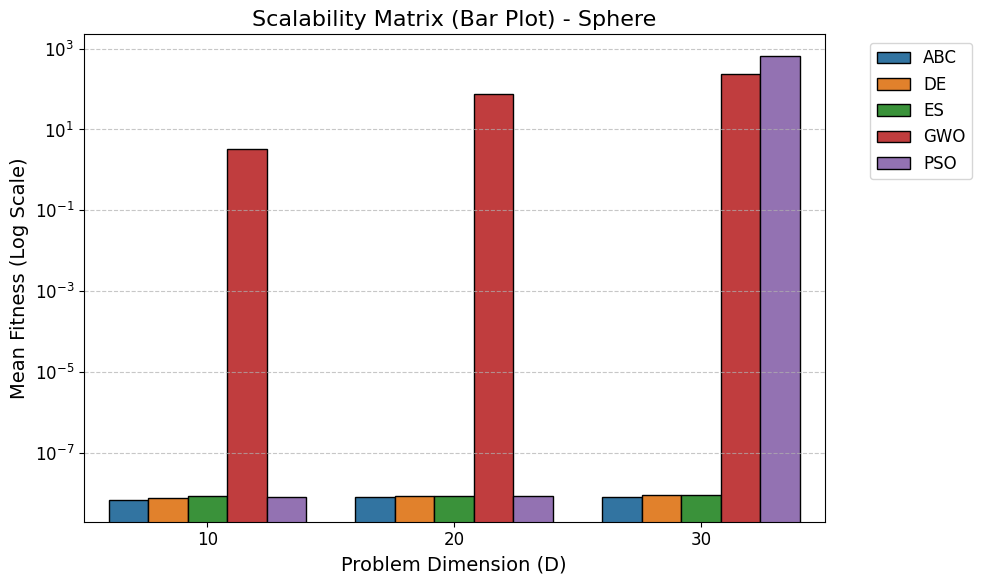

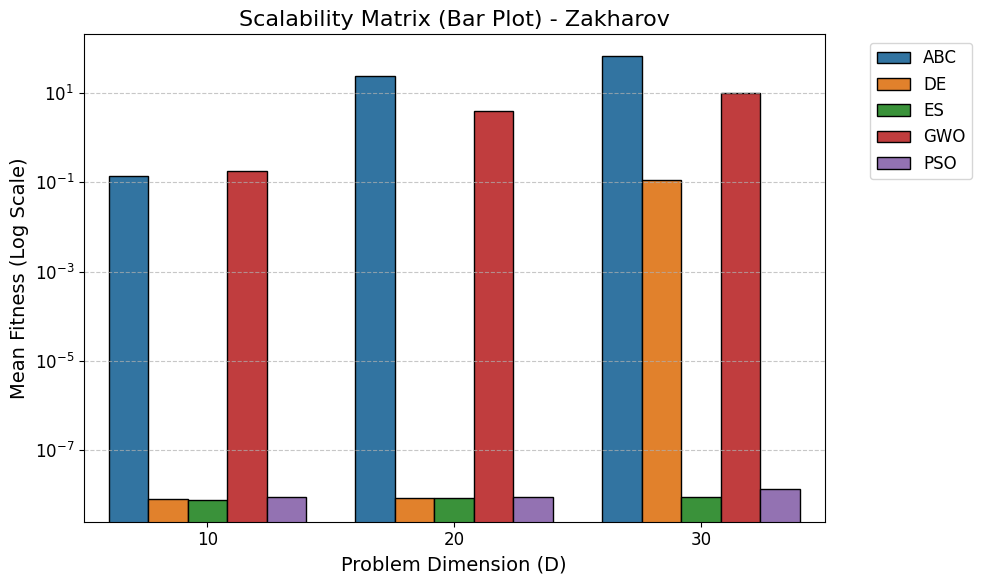

In [2]:
engine.plot_scalability()

## **Convergence Trajectories**

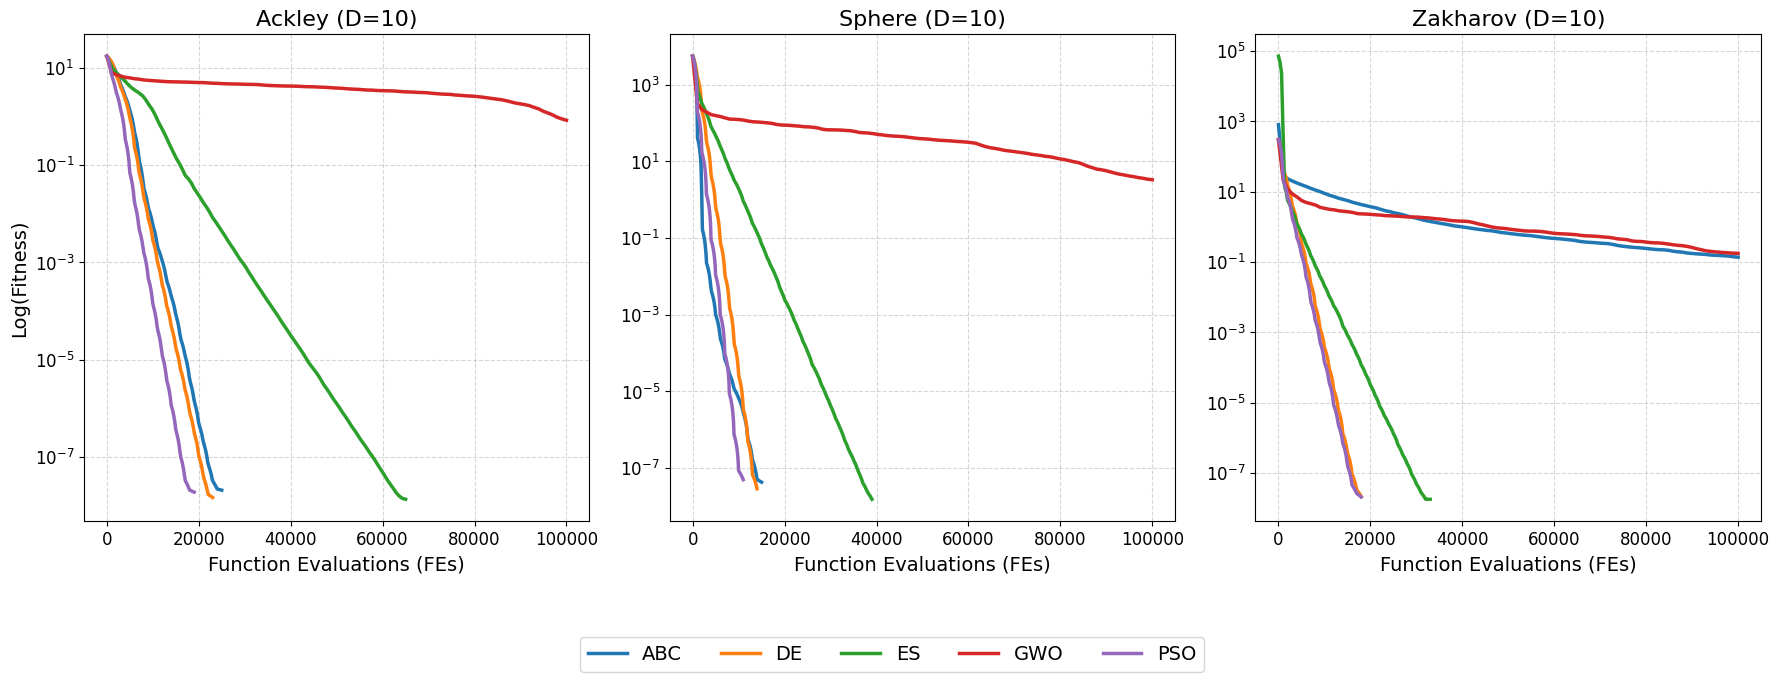

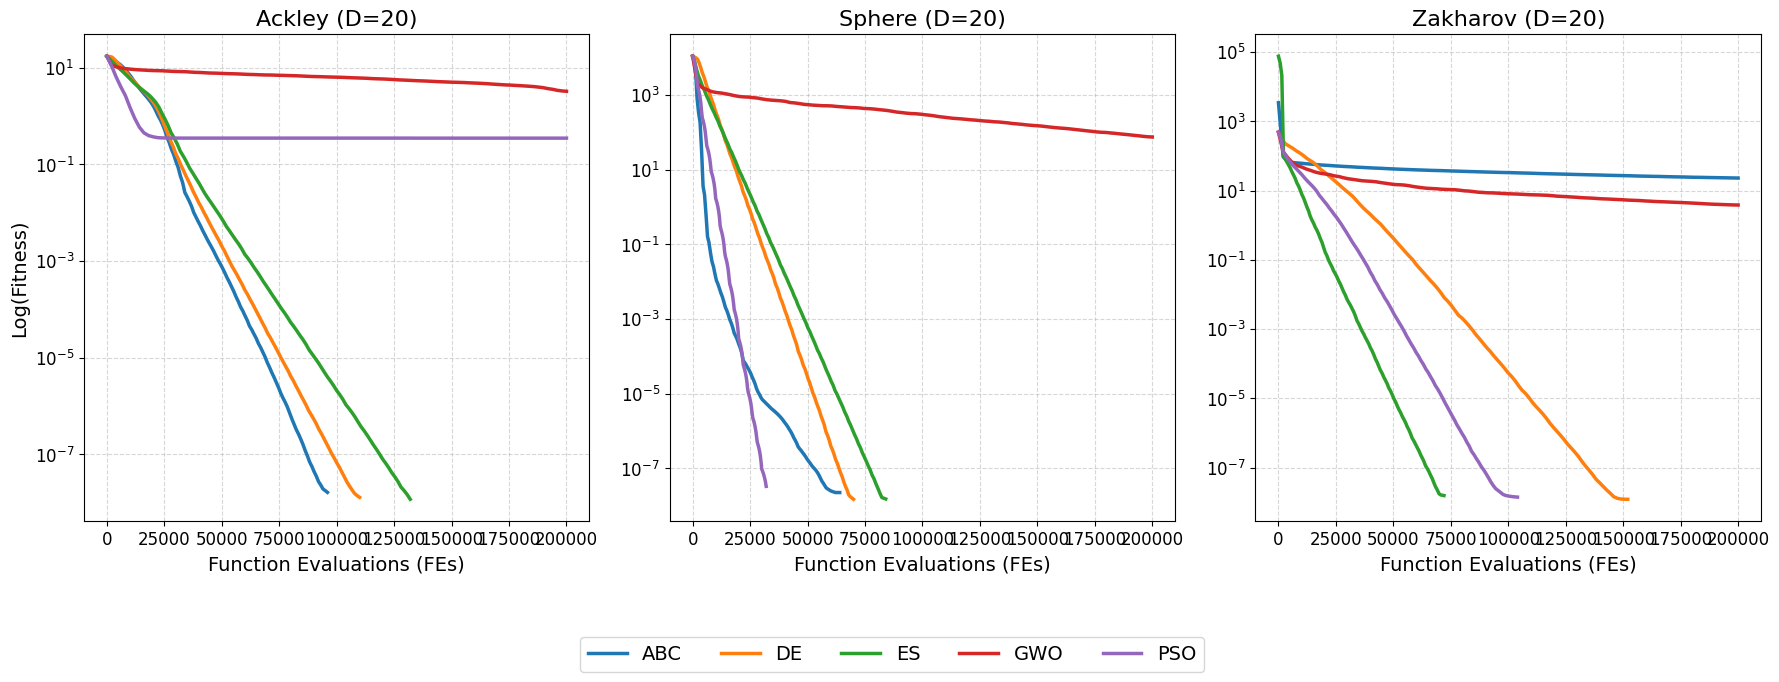

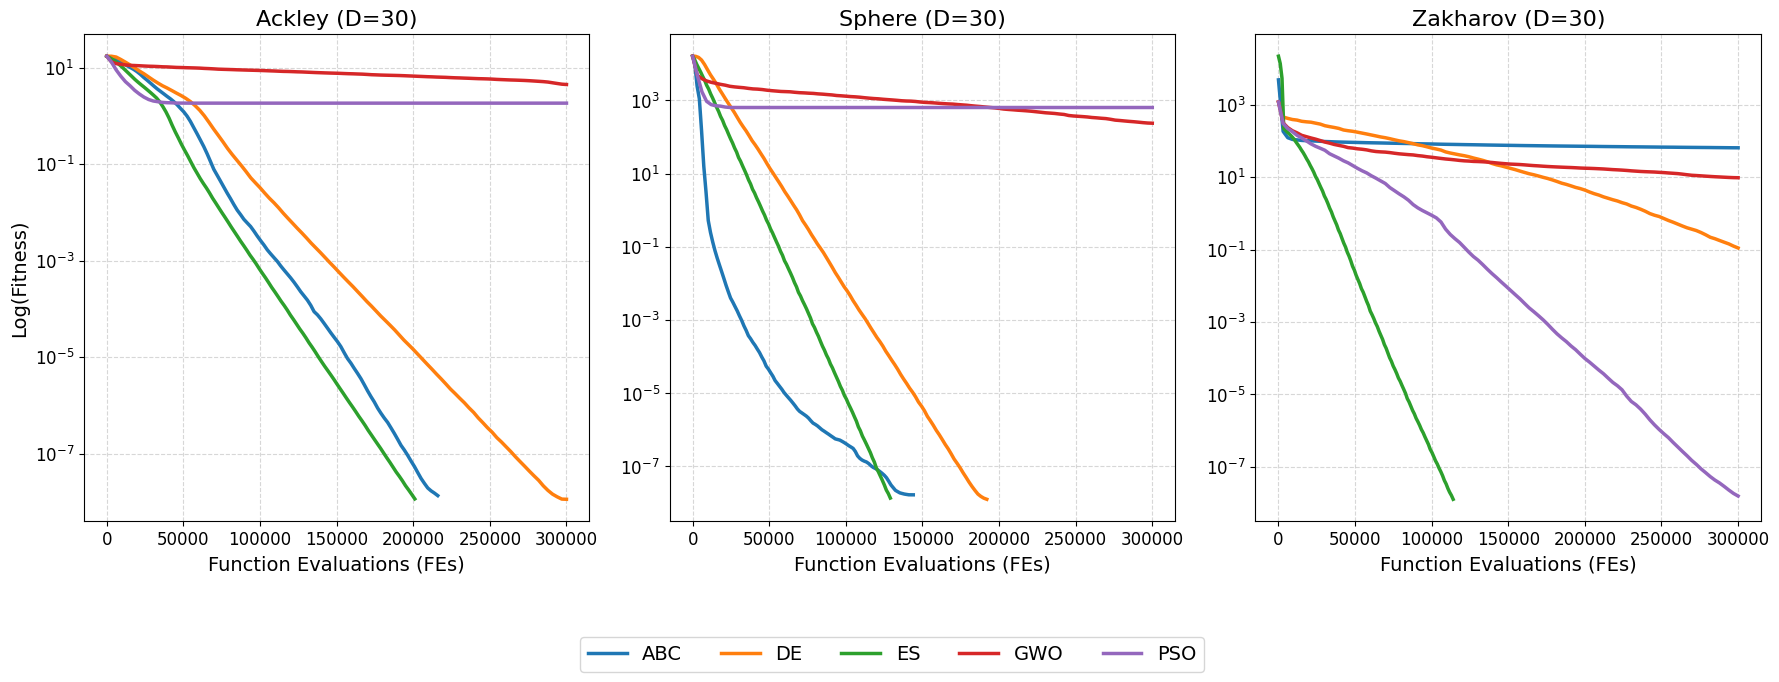

In [2]:
engine.plot_convergence_curves()

## **Computational Cost**

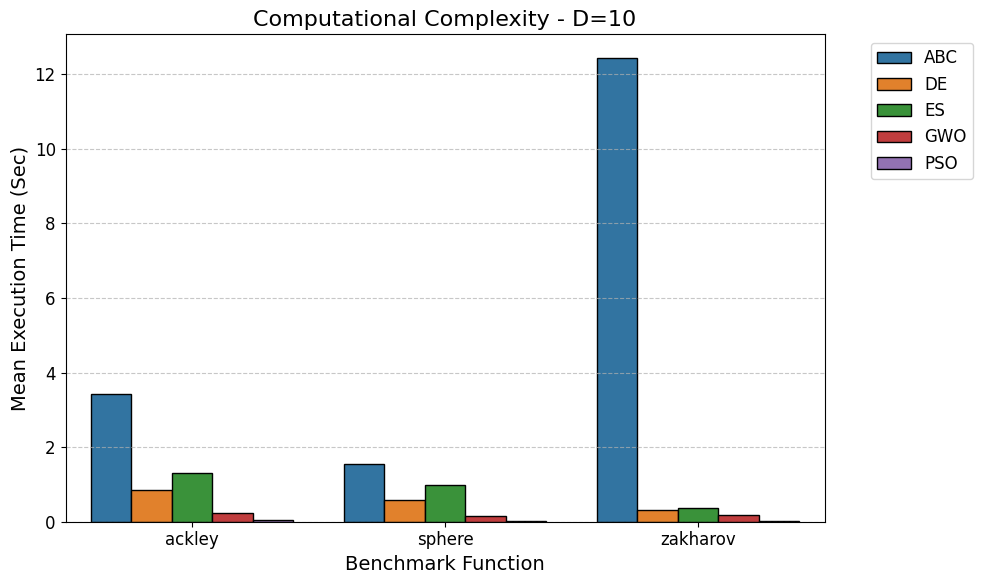

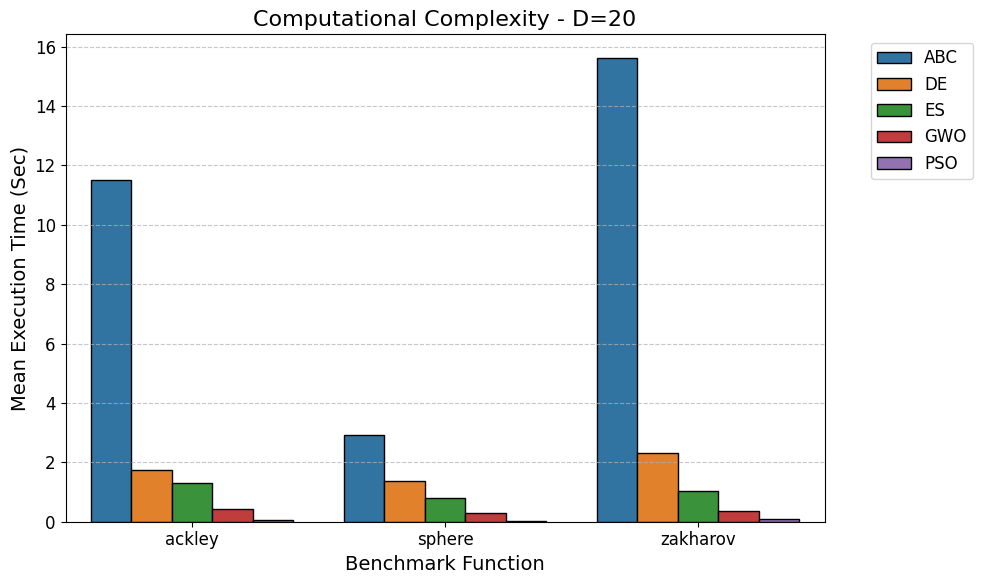

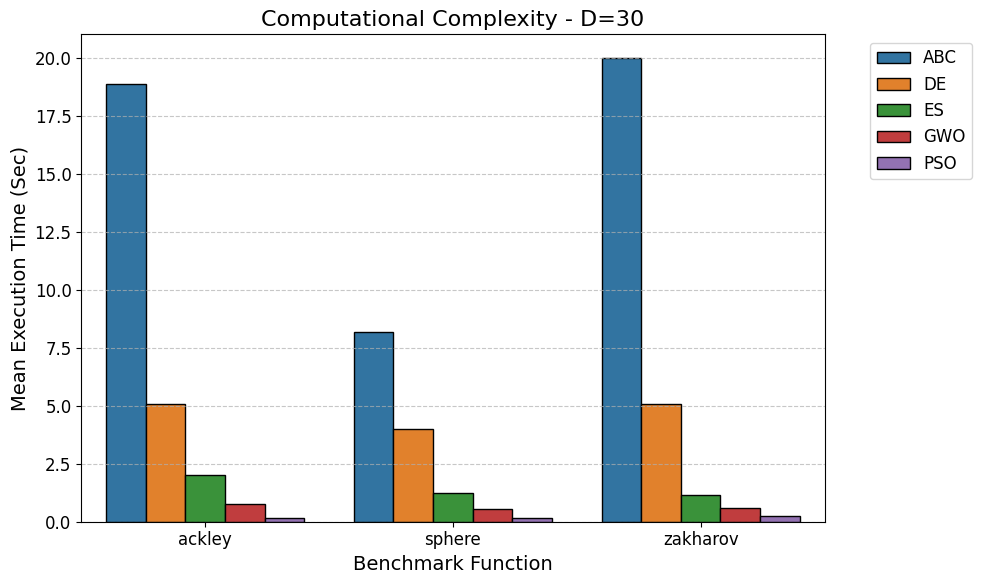

,Function,Algorithm,Time_Sec,Dimension
0,ackley,ABC,3.416923,10
1,ackley,DE,0.847145,10
2,ackley,ES,1.302979,10
3,ackley,GWO,0.226243,10
4,ackley,PSO,0.051934,10
5,sphere,ABC,1.559975,10
6,sphere,DE,0.573132,10
7,sphere,ES,0.991831,10
8,sphere,GWO,0.163541,10
9,sphere,PSO,0.022471,10


In [5]:
engine.plot_computational_cost()

## **Spatial Validation**

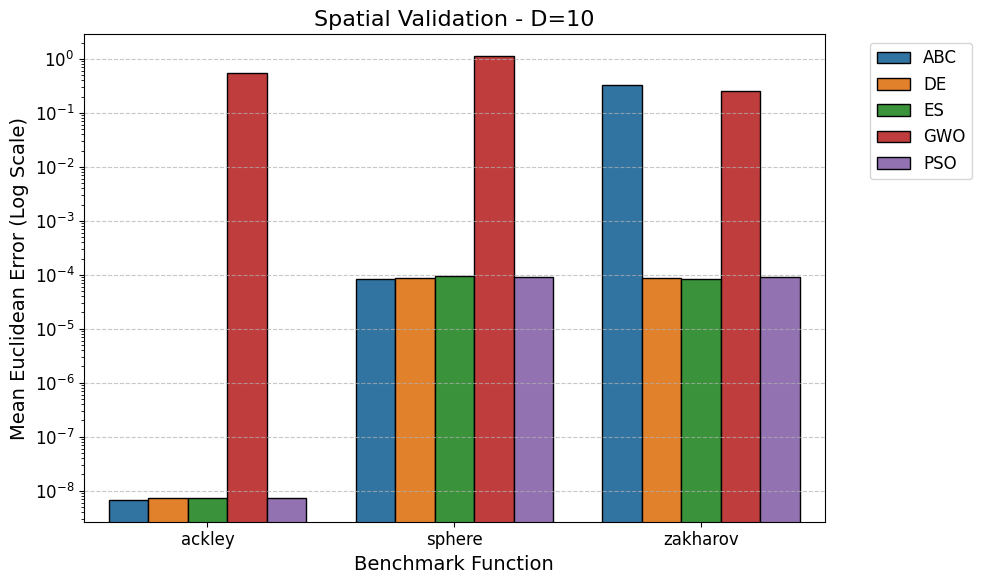

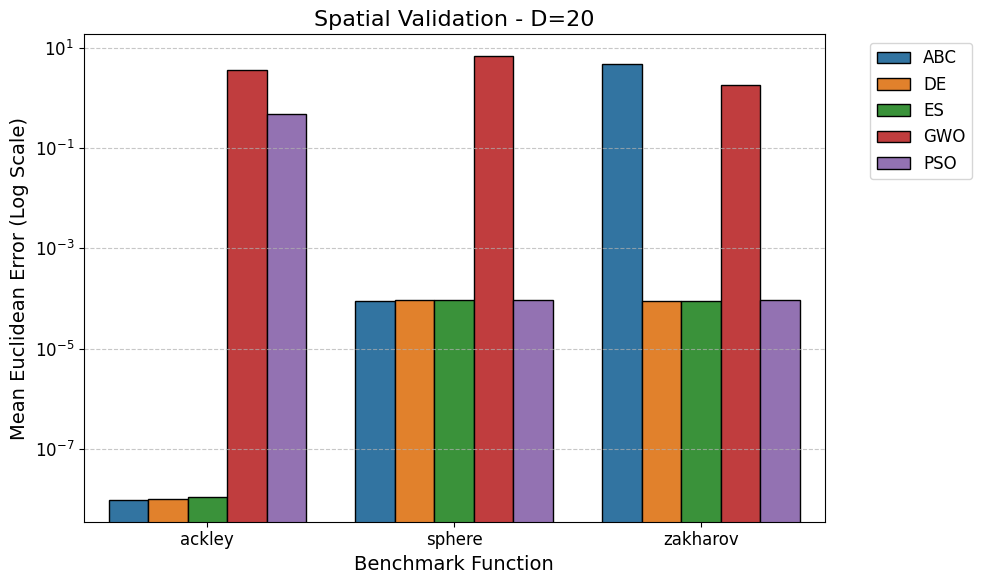

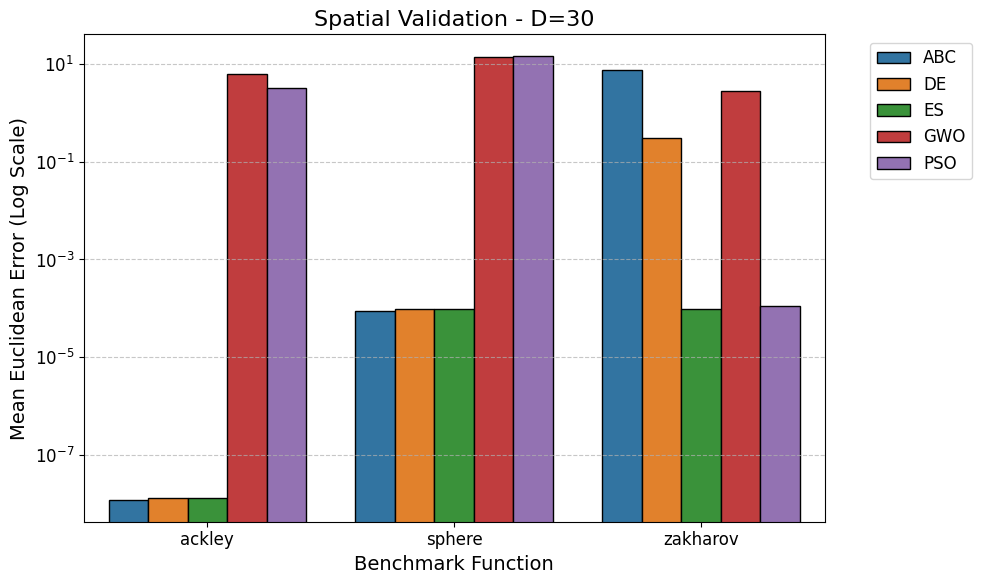

,Function,Algorithm,Euclidean_Error,Dimension
0,ackley,ABC,6.814355e-09,10
1,ackley,DE,7.197661e-09,10
2,ackley,ES,7.164450e-09,10
3,ackley,GWO,5.591311e-01,10
4,ackley,PSO,7.234484e-09,10
5,sphere,ABC,8.251258e-05,10
6,sphere,DE,8.764799e-05,10
7,sphere,ES,9.348271e-05,10
8,sphere,GWO,1.111624e+00,10
9,sphere,PSO,8.964311e-05,10


In [6]:
spatial_error_df = engine.validate_spatial_optimum()
display(spatial_error_df)